# 📊 U.S. Retail Giants Financial Health Analyzer

**Track:** Track 2 – GitHub Data Analysis Project  
**Author:** [Your Name] | [Your Student ID]  
**Institution:** Xi'an Jiaotong-Liverpool University  
**Date:** 2026-04-26

---

## 1. Problem Definition

### 1.1 Analytical Problem

Which of the three major U.S. retail companies — **Walmart (WMT)**, **Costco (COST)**, and **Kroger (KR)** — demonstrates the strongest overall financial health based on fiscal years 2020–2024?

### 1.2 Target Audience

This product is designed for:
- Retail industry investors comparing potential investment options
- Financial analysts conducting peer benchmarking
- Business students learning financial statement analysis with real-world data

### 1.3 Analytical Approach

The tool retrieves real financial statement data from **WRDS Compustat**, calculates **15+ key financial ratios** across four dimensions (profitability, solvency, efficiency, growth), and generates visual comparison reports.

**Four dimensions of analysis:**

| Dimension | Key Metrics |
|:---|:---|
| Profitability | Gross Margin, Net Margin, ROA, ROE |
| Solvency | Current Ratio, Quick Ratio, Debt-to-Assets |
| Efficiency | Inventory Turnover, Receivables Turnover, Asset Turnover |
| Growth | Revenue Growth YoY, Net Income Growth YoY |


## 2. Environment Setup & Data Loading

In [2]:
# =============================================================================
# 2. Environment Setup & Data Loading
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

# Visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print(f"Report Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("Environment setup complete.")

# =============================================================================
# WRDS Connection & Data Retrieval
# =============================================================================

def get_compustat_data(tickers, start_year, end_year):
    """
    Retrieve financial data from WRDS Compustat Fundamentals Annual table.
    
    Key fields retrieved:
    - tic: Ticker Symbol
    - fyear: Fiscal Year
    - datafmt: Data Format (STD = Standard, SUMM_STD = Summary Standard)
    - at: Assets - Total
    - lt: Liabilities - Total
    - ceq: Common Equity - Total
    - act: Current Assets - Total
    - lct: Current Liabilities - Total
    - invt: Inventories - Total
    - rect: Receivables - Total
    - sale: Sales/Turnover (Revenue)
    - cogs: Cost of Goods Sold
    - xsga: Selling, General & Administrative Expense
    - ni: Net Income
    """
    
    try:
        import wrds
    except ImportError:
        print("Error: wrds package not installed. Run: pip install wrds")
        return None, None

    print("Connecting to WRDS database...")
    db = wrds.Connection()
    
    ticker_str = "', '".join(tickers)
    
    sql = f"""
    SELECT 
        tic, datadate, fyear, datafmt,
        at, lt, ceq, act, lct, invt, rect,
        sale, cogs, xsga, ni
    FROM comp.funda
    WHERE tic IN ('{ticker_str}')
        AND fyear BETWEEN {start_year} AND {end_year}
        AND consol = 'C'
        AND popsrc = 'D'
    ORDER BY tic, fyear, datadate DESC
    """
    
    print(f"Querying Compustat for: {tickers}")
    print(f"Year range: {start_year} - {end_year}")
    
    try:
        df_raw = db.raw_sql(sql, date_cols=['datadate'])
        db.close()
        print(f"Retrieved {len(df_raw)} records. Connection closed.")
        
        found_tickers = df_raw['tic'].unique()
        print(f"Companies found: {list(found_tickers)}")
        
        missing = [t for t in tickers if t not in found_tickers]
        if missing:
            print(f"WARNING: No data for: {missing}")
            
    except Exception as e:
        print(f"Query failed: {e}")
        db.rollback()
        db.close()
        return None, None
    
    if len(df_raw) == 0:
        print("ERROR: No data retrieved.")
        return None, None
    
    df_balance, df_income = process_compustat_data(df_raw, tickers)
    return df_balance, df_income

print("Data loading functions defined.")

Report Generated: 2026-04-27 14:38:13
Environment setup complete.
Data loading functions defined.


## 3. Data Cleaning & Preparation

In [2]:
# =============================================================================
# 3. Data Cleaning & Preparation
# =============================================================================

def process_compustat_data(df_raw, tickers):
    """
    Process raw Compustat data into standardized financial statements.
    
    Key cleaning steps:
    1. Extract fiscal year from datadate
    2. Map ticker symbols to company names
    3. Handle missing values (NaN → 0 for numerical columns)
    4. Prioritize STD format over SUMM_STD (STD has more complete data)
    5. Remove duplicate records per company-year
    6. Convert units from millions to billions USD
    """
    
    company_mapping = {
        'WMT': {'name': 'Walmart', 'industry': 'Retail - General Merchandise'},
        'COST': {'name': 'Costco', 'industry': 'Retail - Warehouse Club'},
        'KR': {'name': 'Kroger', 'industry': 'Retail - Supermarket'},
    }
    
    # Step 1: Extract year
    df_raw['Year'] = pd.to_datetime(df_raw['datadate']).dt.year
    
    # Step 2: Map company names
    df_raw['Company'] = df_raw['tic'].map(
        lambda x: company_mapping.get(x, {}).get('name', x)
    )
    df_raw['Ticker'] = df_raw['tic']
    
    # Step 3: Handle missing values
    numeric_cols = ['at', 'lt', 'ceq', 'act', 'lct', 'invt', 'rect', 
                    'sale', 'cogs', 'xsga', 'ni']
    for col in numeric_cols:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
    
    # Step 4: Prioritize STD over SUMM_STD
    if 'datafmt' in df_raw.columns:
        df_raw['data_priority'] = df_raw['datafmt'].map({'STD': 1, 'SUMM_STD': 2}).fillna(3)
    else:
        df_raw['data_priority'] = 1
    
    key_cols = ['at', 'lt', 'ceq', 'sale', 'ni']
    df_raw['completeness'] = df_raw[key_cols].notna().sum(axis=1)
    
    # Step 5: Sort and remove duplicates
    df_raw = df_raw.sort_values(
        ['Ticker', 'Year', 'data_priority', 'completeness', 'datadate'],
        ascending=[True, True, True, False, False]
    )
    df_raw = df_raw.drop_duplicates(subset=['Ticker', 'Year'], keep='first')
    df_raw = df_raw.drop(columns=['data_priority', 'completeness'], errors='ignore')
    
    # Show what was retained
    print("\nRecords retained after deduplication:")
    for tic in df_raw['Ticker'].unique():
        subset = df_raw[df_raw['Ticker'] == tic]
        print(f"\n{company_mapping.get(tic, {}).get('name', tic)} ({tic}): {len(subset)} years")
    
    # Step 6: Unit conversion (millions → billions)
    unit_scale = 1000
    
    # Build Balance Sheet
    df_balance = pd.DataFrame({
        'Ticker': df_raw['Ticker'],
        'Company': df_raw['Company'],
        'Year': df_raw['Year'],
        'Total Assets': df_raw['at'] / unit_scale,
        'Total Liabilities': df_raw['lt'] / unit_scale,
        'Total Equity': df_raw['ceq'] / unit_scale,
        'Current Assets': df_raw['act'] / unit_scale,
        'Current Liabilities': df_raw['lct'] / unit_scale,
        'Inventory': df_raw['invt'] / unit_scale,
        'Accounts Receivable': df_raw['rect'] / unit_scale
    })
    
    # Build Income Statement
    df_income = pd.DataFrame({
        'Ticker': df_raw['Ticker'],
        'Company': df_raw['Company'],
        'Year': df_raw['Year'],
        'Revenue': df_raw['sale'] / unit_scale,
        'COGS': df_raw['cogs'] / unit_scale,
        'SG&A Expense': df_raw['xsga'] / unit_scale,
        'Net Income': df_raw['ni'] / unit_scale
    })
    
    return df_balance, df_income

print("Data cleaning functions defined.")

Data cleaning functions defined.


## 4. Analysis: Financial Ratio Calculation

In [3]:
# =============================================================================
# 4. Analysis: Financial Ratio Calculation
# =============================================================================

def calculate_financial_ratios(df_balance, df_income):
    """
    Calculate 15+ financial ratios across four dimensions.
    
    Dimensions:
    1. Profitability: Gross Margin, Net Margin, ROA, ROE
    2. Solvency: Current Ratio, Quick Ratio, Debt-to-Assets
    3. Efficiency: Inventory Turnover, Receivables Turnover, Asset Turnover
    4. Growth: Revenue Growth YoY, Net Income Growth YoY
    """
    
    # Merge balance sheet and income statement
    df = pd.merge(df_balance, df_income, on=['Ticker', 'Company', 'Year'])
    
    # ===== 1. Profitability Ratios =====
    # Gross Margin: (Revenue - COGS) / Revenue
    df['Gross Margin (%)'] = (df['Revenue'] - df['COGS']) / df['Revenue'] * 100
    
    # Net Margin: Net Income / Revenue
    df['Net Margin (%)'] = df['Net Income'] / df['Revenue'] * 100
    
    # ROA: Net Income / Total Assets
    df['ROA (%)'] = df['Net Income'] / df['Total Assets'] * 100
    
    # ROE: Net Income / Total Equity
    df['ROE (%)'] = df['Net Income'] / df['Total Equity'] * 100
    
    # ===== 2. Solvency Ratios =====
    # Current Ratio: Current Assets / Current Liabilities
    df['Current Ratio'] = df['Current Assets'] / df['Current Liabilities']
    
    # Quick Ratio: (Current Assets - Inventory) / Current Liabilities
    df['Quick Ratio'] = (df['Current Assets'] - df['Inventory']) / df['Current Liabilities']
    
    # Debt-to-Assets: Total Liabilities / Total Assets
    df['Debt-to-Assets (%)'] = df['Total Liabilities'] / df['Total Assets'] * 100
    
    # ===== 3. Efficiency Ratios =====
    # Inventory Turnover: COGS / Inventory
    df['Inventory Turnover'] = df['COGS'] / df['Inventory']
    
    # Receivables Turnover: Revenue / Accounts Receivable
    df['Receivables Turnover'] = df['Revenue'] / df['Accounts Receivable']
    
    # Asset Turnover: Revenue / Total Assets
    df['Asset Turnover'] = df['Revenue'] / df['Total Assets']
    
    # ===== 4. Growth Ratios =====
    df_sorted = df.sort_values(['Ticker', 'Year'])
    
    # Revenue Growth YoY
    df['Revenue Growth YoY (%)'] = df_sorted.groupby('Ticker')['Revenue'].pct_change() * 100
    
    # Net Income Growth YoY
    df['Net Income Growth YoY (%)'] = df_sorted.groupby('Ticker')['Net Income'].pct_change() * 100
    
    return df

print("Ratio calculation engine ready.")

Ratio calculation engine ready.


## 5. Output: Tables, Charts & Results

Executing Full Analysis Pipeline
Connecting to WRDS database...


Enter your WRDS username [HP]: rorowan
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\HP\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Querying Compustat for: ['WMT', 'COST', 'KR']
Year range: 2020 - 2024
Retrieved 30 records. Connection closed.
Companies found: ['COST', 'KR', 'WMT']

Records retained after deduplication:

Costco (COST): 5 years

Kroger (KR): 5 years

Walmart (WMT): 5 years

Analysis year: 2024
Table 1: Key Financial Ratios - 2024


,Company,Gross Margin (%),Net Margin (%),ROE (%),Current Ratio,Debt-to-Assets (%),Inventory Turnover,Revenue Growth YoY (%)
4,Costco,13.490000,2.900000,31.190000,0.970000,66.170000,11.800000,5.020000
8,Kroger,22.240000,1.440000,18.630000,0.810000,77.030000,16.420000,1.200000
13,Walmart,25.930000,2.400000,18.500000,0.830000,64.120000,8.710000,6.120000



Chart 1: Profitability Comparison


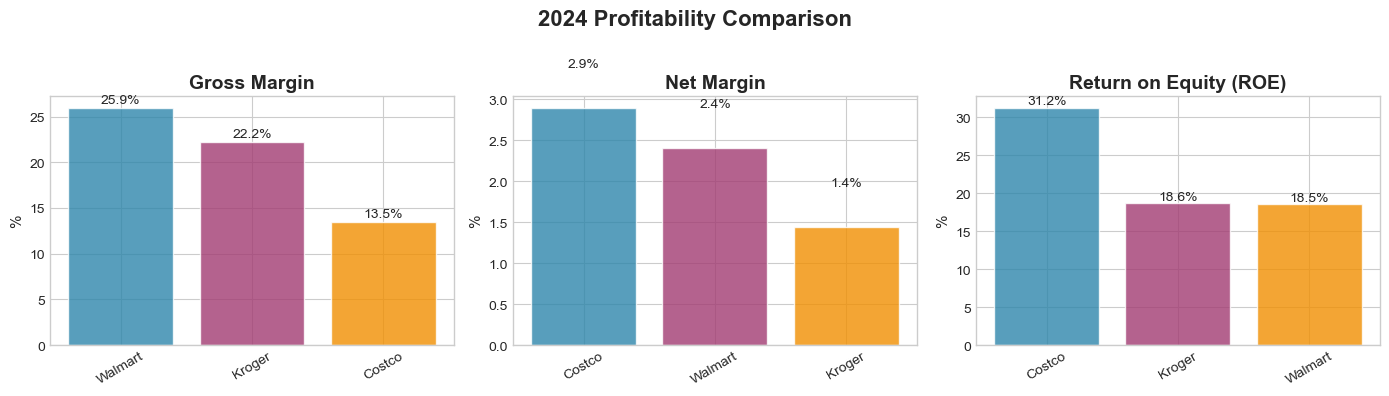


Chart 2: Multi-Dimensional Radar Chart


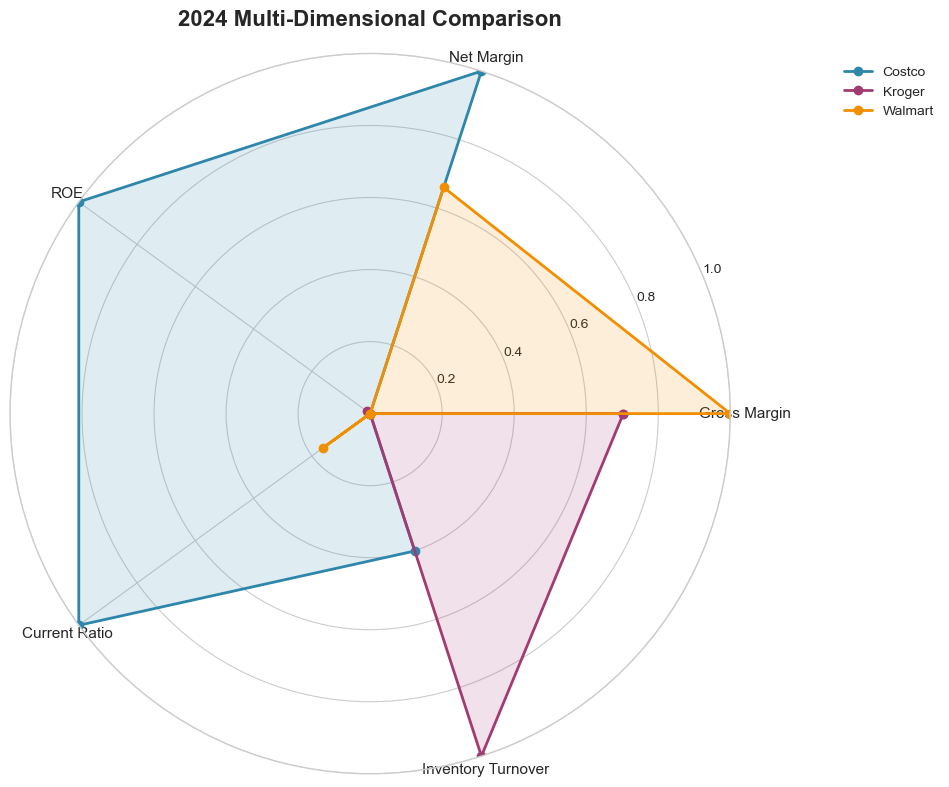


Chart: Costco Trend Analysis


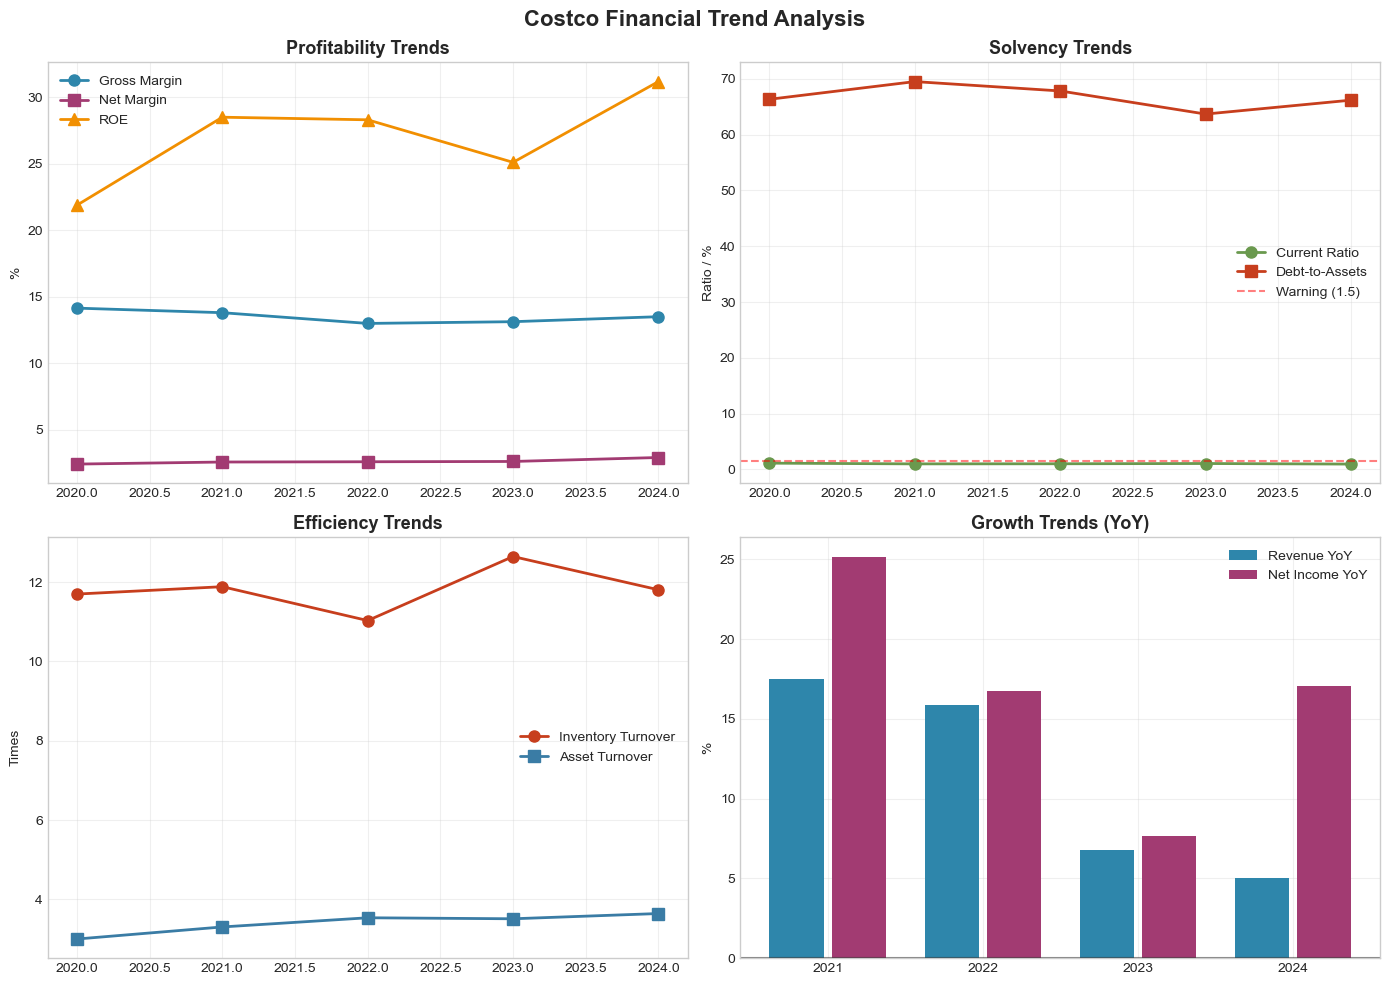


Chart: Kroger Trend Analysis


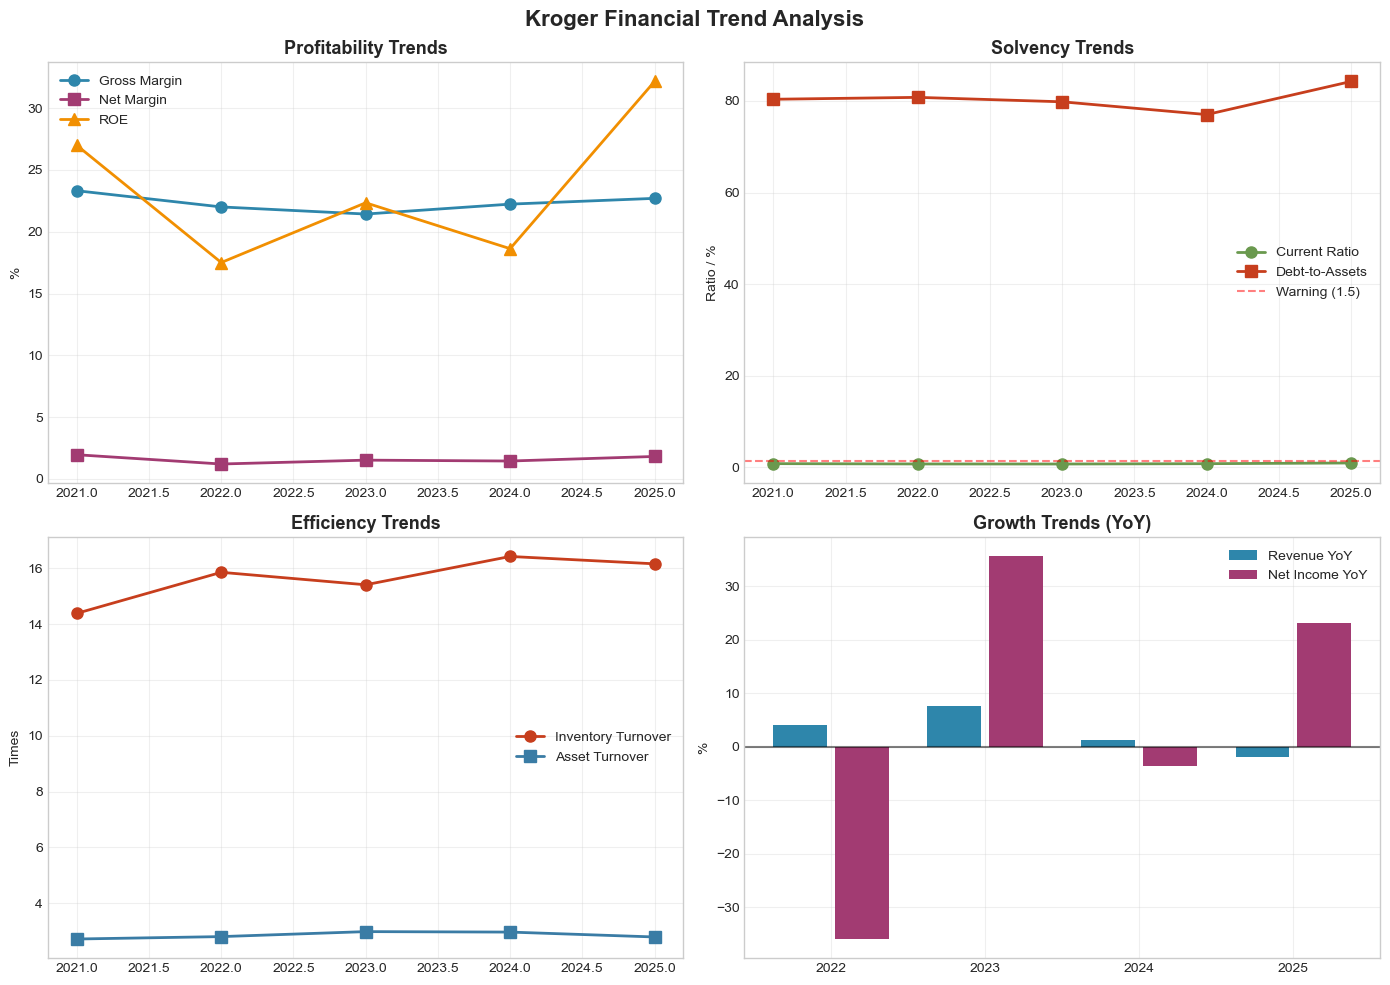


Chart: Walmart Trend Analysis


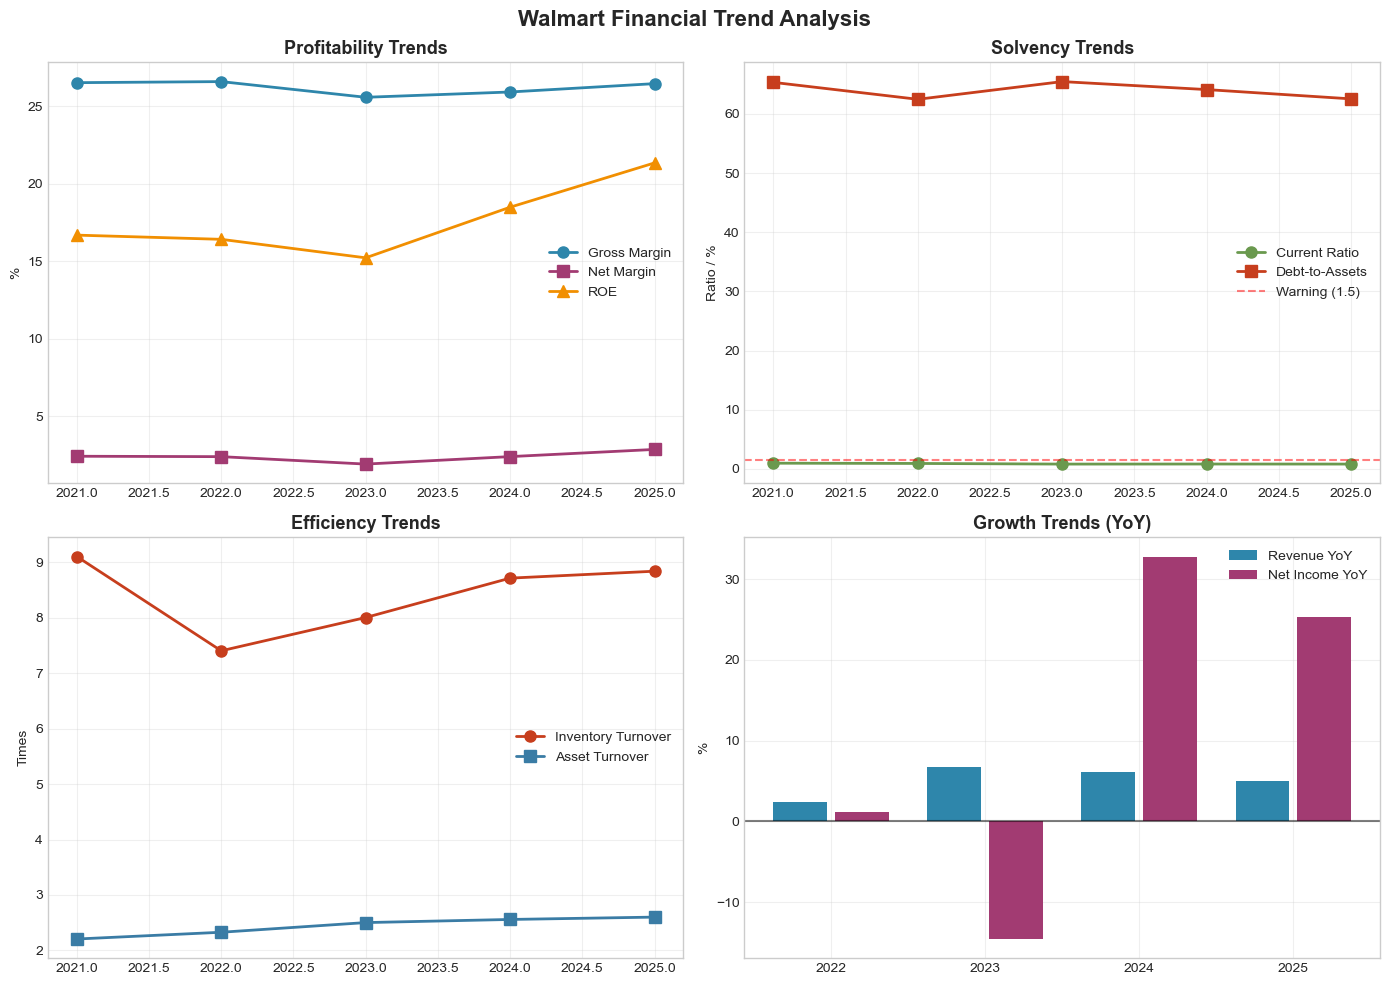

Key Insights Summary

Gross Margin (%):
  Best:  Walmart (25.93)
  Worst: Costco (13.49)

Net Margin (%):
  Best:  Costco (2.90)
  Worst: Kroger (1.44)

ROE (%):
  Best:  Costco (31.19)
  Worst: Walmart (18.50)

Inventory Turnover:
  Best:  Kroger (16.42)
  Worst: Walmart (8.71)

Debt-to-Assets (%) — Lower is Better:
  Best:  Walmart (64.12%)
  Worst: Kroger (77.03%)

Data Provenance
Source: WRDS - Compustat North America, Fundamentals Annual
Companies: Costco, Kroger, Walmart
Period: FY 2020 - 2024
Analysis Date: 2026-04-26


In [5]:
# =============================================================================
# 5. Output: Tables, Charts & Results
# =============================================================================

# ----- 5.1 Data Loading & Processing -----
TICKERS = ['WMT', 'COST', 'KR']
START_YEAR = 2020
END_YEAR = 2024

print("=" * 60)
print("Executing Full Analysis Pipeline")
print("=" * 60)

df_balance, df_income = get_compustat_data(TICKERS, START_YEAR, END_YEAR)
df_ratios = calculate_financial_ratios(df_balance, df_income)

# Use 2024 as latest common year
latest_year = 2024

print(f"\nAnalysis year: {latest_year}")

# ----- 5.2 Summary Table: Key Financial Ratios -----

print("=" * 60)
print(f"Table 1: Key Financial Ratios - {latest_year}")
print("=" * 60)

display_cols = [
    'Company', 'Gross Margin (%)', 'Net Margin (%)', 'ROE (%)',
    'Current Ratio', 'Debt-to-Assets (%)', 'Inventory Turnover',
    'Revenue Growth YoY (%)'
]

df_display = df_ratios[df_ratios['Year'] == latest_year][display_cols].round(2)
display(df_display.style.background_gradient(cmap='RdYlGn', subset=['Gross Margin (%)', 'Net Margin (%)', 'ROE (%)']))

# ----- 5.3 Chart 1: Profitability Comparison -----

def plot_profitability_comparison(df, year):
    """Generate side-by-side profitability comparison."""
    df_year = df[df['Year'] == year].copy()
    
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    metrics = ['Gross Margin (%)', 'Net Margin (%)', 'ROE (%)']
    titles = ['Gross Margin', 'Net Margin', 'Return on Equity (ROE)']
    colors = ['#2E86AB', '#A23B72', '#F18F01']
    
    for i, (metric, title) in enumerate(zip(metrics, titles)):
        df_sorted = df_year.sort_values(metric, ascending=False)
        bars = axes[i].bar(df_sorted['Company'], df_sorted[metric], 
                          color=colors, alpha=0.8, edgecolor='white')
        axes[i].set_title(title, fontsize=14, fontweight='bold')
        axes[i].set_ylabel('%', fontsize=11)
        axes[i].tick_params(axis='x', rotation=30)
        
        for bar, val in zip(bars, df_sorted[metric]):
            if not np.isnan(val):
                axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                            f'{val:.1f}%', ha='center', fontsize=10)
    
    plt.suptitle(f'{year} Profitability Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    return fig

print("\nChart 1: Profitability Comparison")
fig1 = plot_profitability_comparison(df_ratios, latest_year)
os.makedirs('images', exist_ok=True)
fig1.savefig('images/profitability_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ----- 5.4 Chart 2: Multi-Dimensional Radar Chart -----

def plot_radar_chart(df, year):
    """Generate radar chart for multi-dimensional comparison."""
    df_year = df[df['Year'] == year].copy()
    
    metrics = ['Gross Margin (%)', 'Net Margin (%)', 'ROE (%)', 'Current Ratio', 'Inventory Turnover']
    labels = ['Gross Margin', 'Net Margin', 'ROE', 'Current Ratio', 'Inventory Turnover']
    
    # Normalize
    df_norm = df_year.copy()
    for m in metrics:
        if m in df_norm.columns and df_norm[m].notna().any():
            max_v, min_v = df_norm[m].max(), df_norm[m].min()
            df_norm[f'{m}_norm'] = (df_norm[m] - min_v) / (max_v - min_v) if max_v > min_v else 0.5
        else:
            df_norm[f'{m}_norm'] = 0.5
    
    N = len(metrics)
    angles = [n / N * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))
    colors = ['#2E86AB', '#A23B72', '#F18F01']
    
    for i, company in enumerate(df_norm['Company'].unique()):
        values = [df_norm[df_norm['Company'] == company][f'{m}_norm'].values[0] for m in metrics]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=company, color=colors[i])
        ax.fill(angles, values, alpha=0.15, color=colors[i])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_title(f'{year} Multi-Dimensional Comparison', fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax.grid(True)
    
    plt.tight_layout()
    return fig

print("\nChart 2: Multi-Dimensional Radar Chart")
fig2 = plot_radar_chart(df_ratios, latest_year)
fig2.savefig('images/radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

# ----- 5.5 Chart 3: Trend Analysis for Each Company -----

def plot_trend(df, company_name):
    """Generate four-panel trend analysis for a single company."""
    df_company = df[df['Company'] == company_name].sort_values('Year')
    
    if df_company.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.text(0.5, 0.5, f'No Data for {company_name}', ha='center', va='center', fontsize=14)
        return fig
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Profitability
    ax1 = axes[0, 0]
    ax1.plot(df_company['Year'], df_company['Gross Margin (%)'], 'o-', color='#2E86AB', linewidth=2, markersize=8, label='Gross Margin')
    ax1.plot(df_company['Year'], df_company['Net Margin (%)'], 's-', color='#A23B72', linewidth=2, markersize=8, label='Net Margin')
    ax1.plot(df_company['Year'], df_company['ROE (%)'], '^-', color='#F18F01', linewidth=2, markersize=8, label='ROE')
    ax1.set_title('Profitability Trends', fontsize=13, fontweight='bold')
    ax1.set_ylabel('%')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    
    # Solvency
    ax2 = axes[0, 1]
    ax2.plot(df_company['Year'], df_company['Current Ratio'], 'o-', color='#6A994E', linewidth=2, markersize=8, label='Current Ratio')
    ax2.plot(df_company['Year'], df_company['Debt-to-Assets (%)'], 's-', color='#C73E1D', linewidth=2, markersize=8, label='Debt-to-Assets')
    ax2.axhline(y=1.5, color='red', linestyle='--', alpha=0.5, label='Warning (1.5)')
    ax2.set_title('Solvency Trends', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Ratio / %')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    
    # Efficiency
    ax3 = axes[1, 0]
    ax3.plot(df_company['Year'], df_company['Inventory Turnover'], 'o-', color='#C73E1D', linewidth=2, markersize=8, label='Inventory Turnover')
    ax3.plot(df_company['Year'], df_company['Asset Turnover'], 's-', color='#3A7CA5', linewidth=2, markersize=8, label='Asset Turnover')
    ax3.set_title('Efficiency Trends', fontsize=13, fontweight='bold')
    ax3.set_ylabel('Times')
    ax3.legend(); ax3.grid(True, alpha=0.3)
    
    # Growth
    ax4 = axes[1, 1]
    if len(df_company) > 1:
        years = df_company['Year'].values[1:]
        rev_g = df_company['Revenue Growth YoY (%)'].values[1:]
        ni_g = df_company['Net Income Growth YoY (%)'].values[1:]
        x = np.arange(len(years))
        ax4.bar(x - 0.2, rev_g, 0.35, label='Revenue YoY', color='#2E86AB')
        ax4.bar(x + 0.2, ni_g, 0.35, label='Net Income YoY', color='#A23B72')
        ax4.axhline(y=0, color='black', alpha=0.5)
        ax4.set_xticks(x); ax4.set_xticklabels(years)
    ax4.set_title('Growth Trends (YoY)', fontsize=13, fontweight='bold')
    ax4.set_ylabel('%')
    ax4.legend(); ax4.grid(True, alpha=0.3)
    
    plt.suptitle(f'{company_name} Financial Trend Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    return fig

company_file_map = {'Walmart': 'trend_wmt', 'Costco': 'trend_cost', 'Kroger': 'trend_kr'}
companies_found = df_ratios['Company'].unique()

for company in companies_found:
    print(f"\nChart: {company} Trend Analysis")
    fig = plot_trend(df_ratios, company)
    file_key = company_file_map.get(company, company.lower().replace(' ', '_'))
    fig.savefig(f'images/{file_key}.png', dpi=300, bbox_inches='tight')
    plt.show()

# ----- 5.6 Key Insights Summary -----

print("=" * 60)
print("Key Insights Summary")
print("=" * 60)

df_2024 = df_ratios[df_ratios['Year'] == 2024]

for metric in ['Gross Margin (%)', 'Net Margin (%)', 'ROE (%)', 'Inventory Turnover']:
    best = df_2024.loc[df_2024[metric].idxmax()]
    worst = df_2024.loc[df_2024[metric].idxmin()]
    print(f"\n{metric}:")
    print(f"  Best:  {best['Company']} ({best[metric]:.2f})")
    print(f"  Worst: {worst['Company']} ({worst[metric]:.2f})")

# Debt-to-Assets is reverse (lower is better)
print(f"\nDebt-to-Assets (%) — Lower is Better:")
best_da = df_2024.loc[df_2024['Debt-to-Assets (%)'].idxmin()]
worst_da = df_2024.loc[df_2024['Debt-to-Assets (%)'].idxmax()]
print(f"  Best:  {best_da['Company']} ({best_da['Debt-to-Assets (%)']:.2f}%)")
print(f"  Worst: {worst_da['Company']} ({worst_da['Debt-to-Assets (%)']:.2f}%)")

print("\n" + "=" * 60)
print("Data Provenance")
print("=" * 60)
print(f"Source: WRDS - Compustat North America, Fundamentals Annual")
print(f"Companies: {', '.join(companies_found)}")
print(f"Period: FY {START_YEAR} - {END_YEAR}")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d')}")

## Workflow Summary

| Step | Description | Output |
|:---|:---|:---|
| 1. Problem Definition | Define analytical question and target audience | Markdown cells above |
| 2. Data Loading | Connect to WRDS, query Compustat funda table | Raw DataFrame |
| 3. Data Cleaning | Handle missing values, deduplicate, convert units | Cleaned balance sheet & income statement |
| 4. Analysis | Calculate 15+ financial ratios across 4 dimensions | Ratio DataFrame |
| 5. Output | Generate tables, charts, and insight summary | Summary table + 5 visualizations |

---